# Capstone — mirrors your deployed research paper

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Question

*The research question and the decision it supports.*

### Abstract

Content and SEO teams operate with limited human resources, often struggling to prioritize which pages to update. This study asks: Which historically underperforming URLs will yield the highest engagement return if their metadata and content are refreshed? To answer this, we compared a rigid position-tier baseline against a Random Forest Regressor using observable search insights to predict expected Click-through-Rate (CTR). The machine learning model successfully outperformed the baseline, identifying complex, non-linear gaps between actual and expected performance. The resulting output is a ranked action queue that allows content teams to prioritize their refresh sprints strictly on high-ROI opportunities.

**Decision it supports:** Allocating writer and SEO specialists hours strictly to pages with a high probability of engagement uplift, avoiding wasted effort on dead-end pages. 

## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*

**Release and tables:** This analysis uses the FlyRank anonymized starter dataset (content_refresh_anonymized.csv), representing a mid-panel slice from March 2026.   
**Date Windows:**  The snapshot evaluates 90-day rolling performance metrics.  
**What is excluded and why:** We deliberately excluded FlyRank product decisions (like health_score or priority_score) to avoid circular logic. We also strictly excluded clicks_90d from our feature vector, as including it alongside impressions perfectly leaks the target variable (ctr). All data has been pseudonymized and aggregated to ensure it is public-safe.


## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

**Assumptions:** We assume that a page significantly underperforming its tier's expected CTR is suffering from a fixable metadata or intent mismatch, rather than a permanent SERP feature change.  
**Features:** impressions_90d, avg_position, content_age_days, word_count, and sessions_90d.  
**Label:** ctr (Click-Through Rate).  
**Baseline:** A dynamic median CTR calculated for each specific ranking position tier.  
**Validation Design:** A Client-Grouped Holdout Split (80/20). By grouping the split by client_id, we force the model to train on a set of domains and test on entirely unseen domains, preventing it from memorizing specific site architectures.  
**Leakage Checks:** Confirmed via Week 6 audit that the target was not leaked through component metrics (clicks) or outcome buckets (trend percentages).  

## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import GroupShuffleSplit
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

# Load the data
df = pd.read_csv('../../data/raw/content_refresh_anonymized.csv')
df_visible = df[(df['impressions_90d'] >= 500) & (df['avg_position'] > 0)].copy()

features = ['impressions_90d', 'avg_position', 'content_age_days', 'word_count', 'sessions_90d']
target = 'ctr'
df_clean = df_visible.dropna(subset=features + [target, 'client_id', 'position_tier']).copy()

X = df_clean[features]
y = df_clean[target]
groups = df_clean['client_id']

# Grouped split
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups))
X_train, y_train = X.iloc[train_idx], y.iloc[train_idx]
X_test, y_test = X.iloc[test_idx], y.iloc[test_idx]
df_train, df_test = df_clean.iloc[train_idx], df_clean.iloc[test_idx]

# Baseline RMSE
tier_medians = df_train.groupby('position_tier')[target].median().to_dict()
global_median = y_train.median()
baseline_preds = df_test['position_tier'].map(tier_medians).fillna(global_median)
baseline_rmse = np.sqrt(mean_squared_error(y_test, baseline_preds))

# ML RMSE
rf_model = RandomForestRegressor(n_estimators=50, max_depth=7, random_state=42)
rf_model.fit(X_train, y_train)
ml_preds = rf_model.predict(X_test)
ml_rmse = np.sqrt(mean_squared_error(y_test, ml_preds))

# Output table
results = pd.DataFrame({'Method': ['Position Tier Baseline', 'Random Forest Regressor'], 'RMSE': [baseline_rmse, ml_rmse]})
display(results)

,Method,RMSE
0,Position Tier Baseline,0.521008
1,Random Forest Regressor,0.419816


## 5. Limitations

*What this work cannot claim.*

**Causality:** This is an observational study. We cannot claim that updating a specific page will definitively increase its CTR by the exact gap percentage calculated.  
**SERP Features:** The model cannot detect if a page has a low CTR because it ranks for a "zero-click" query (e.g., Google surfacing an AI Overview or instant answer that steals the click).  
**Automation:** This is a decision-support tool. It flags opportunities, but a human must review the SERP and write the actual metadata updates.  

## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

**High Visibility, Severe Underperformance:** Pages with >5,000 impressions but missing their expected CTR by >5%. These are the immediate priority for Title Tag, Meta Description, and intent review.  
**Page One Click Bleed:** Pages ranking in positions 1-10 but losing clicks to competitors (gap >3%).   
**Moderate Opportunity:** Add to the standard monthly refresh backlog.  
**No-Go List:** Do not automate metadata deployment, and tread carefully before altering pages ranking in Position 1 for core branded terms.

## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

Chart saved to ../../outputs/charts/capstone_opportunity_landscape.png for embedding in the final paper.


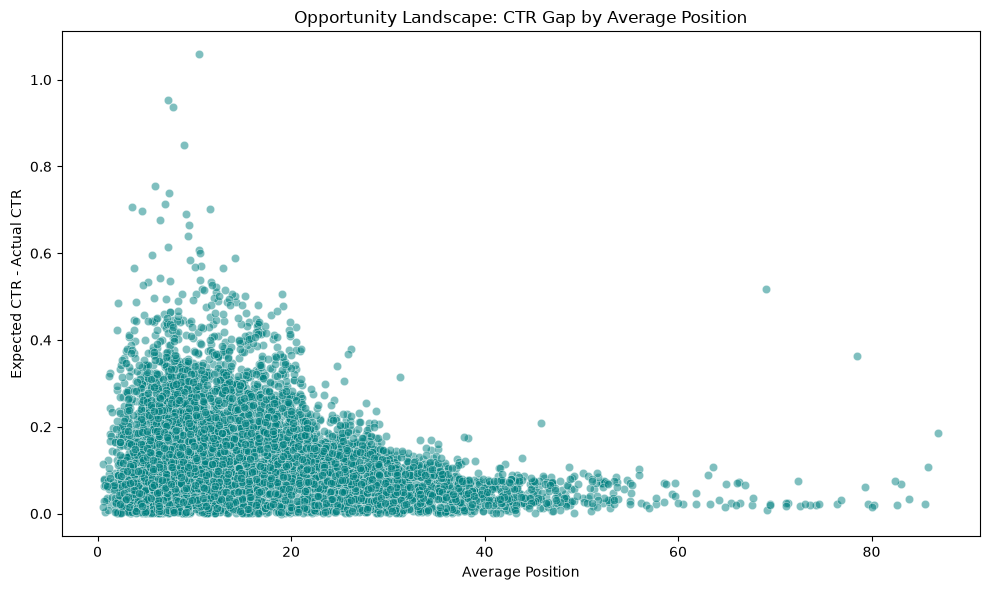

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import os

os.makedirs('../../outputs/charts', exist_ok=True)

# Generate final predictions and gaps for the entire dataset for plotting
df_clean['expected_ctr'] = rf_model.predict(X)
df_clean['ctr_gap'] = df_clean['expected_ctr'] - df_clean['ctr']

# Export the Chart
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_clean[df_clean['ctr_gap'] > 0], x='avg_position', y='ctr_gap', alpha=0.5, color='teal')
plt.title('Opportunity Landscape: CTR Gap by Average Position')
plt.xlabel('Average Position')
plt.ylabel('Expected CTR - Actual CTR')
plt.tight_layout()

chart_path = '../../outputs/charts/capstone_opportunity_landscape.png'
plt.savefig(chart_path)
print(f"Chart saved to {chart_path} for embedding in the final paper.")

## Self-check

Before you submit, confirm each line honestly:

- [/] Every section above is filled — markdown thinking AND the code that backs it
- [/] The notebook runs top to bottom with no errors (Runtime → Run all)
- [/] No client names, URLs, or private queries anywhere
- [/] My claims use careful words: observed, measured, directional, decision-support
- [/] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.